# Import the required libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score

# Load dataset

In [26]:
df=pd.read_csv("Iris.csv")
df.drop(columns=["Id"])
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Get an Idea on DF

In [27]:
print(df.info())
print("Shape of the dataset is:",df.shape)
print("\nColumn Names:",list(df.columns))
print("\nClass distribution:")
print(df["Species"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
Shape of the dataset is: (150, 6)

Column Names: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Class distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


# Check for missing and null values

In [28]:
missing=df.isnull().sum()
print("Missing values per column:\n")
print(missing)
print("\nTotal missing values:",df.isnull().sum().sum())

Missing values per column:

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Total missing values: 0


# Description

In [29]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [30]:
df.describe(include="object")

,Species
count,150
unique,3
top,Iris-setosa
freq,50


# Exploratory Data Analysis

# Count plot

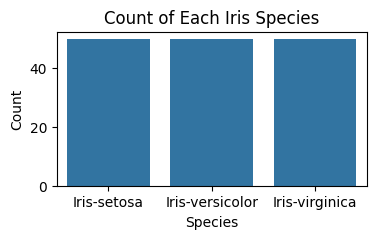

In [31]:
plt.figure(figsize=(4,2))
sns.countplot(data=df,x="Species")
plt.title("Count of Each Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

# Pairplot

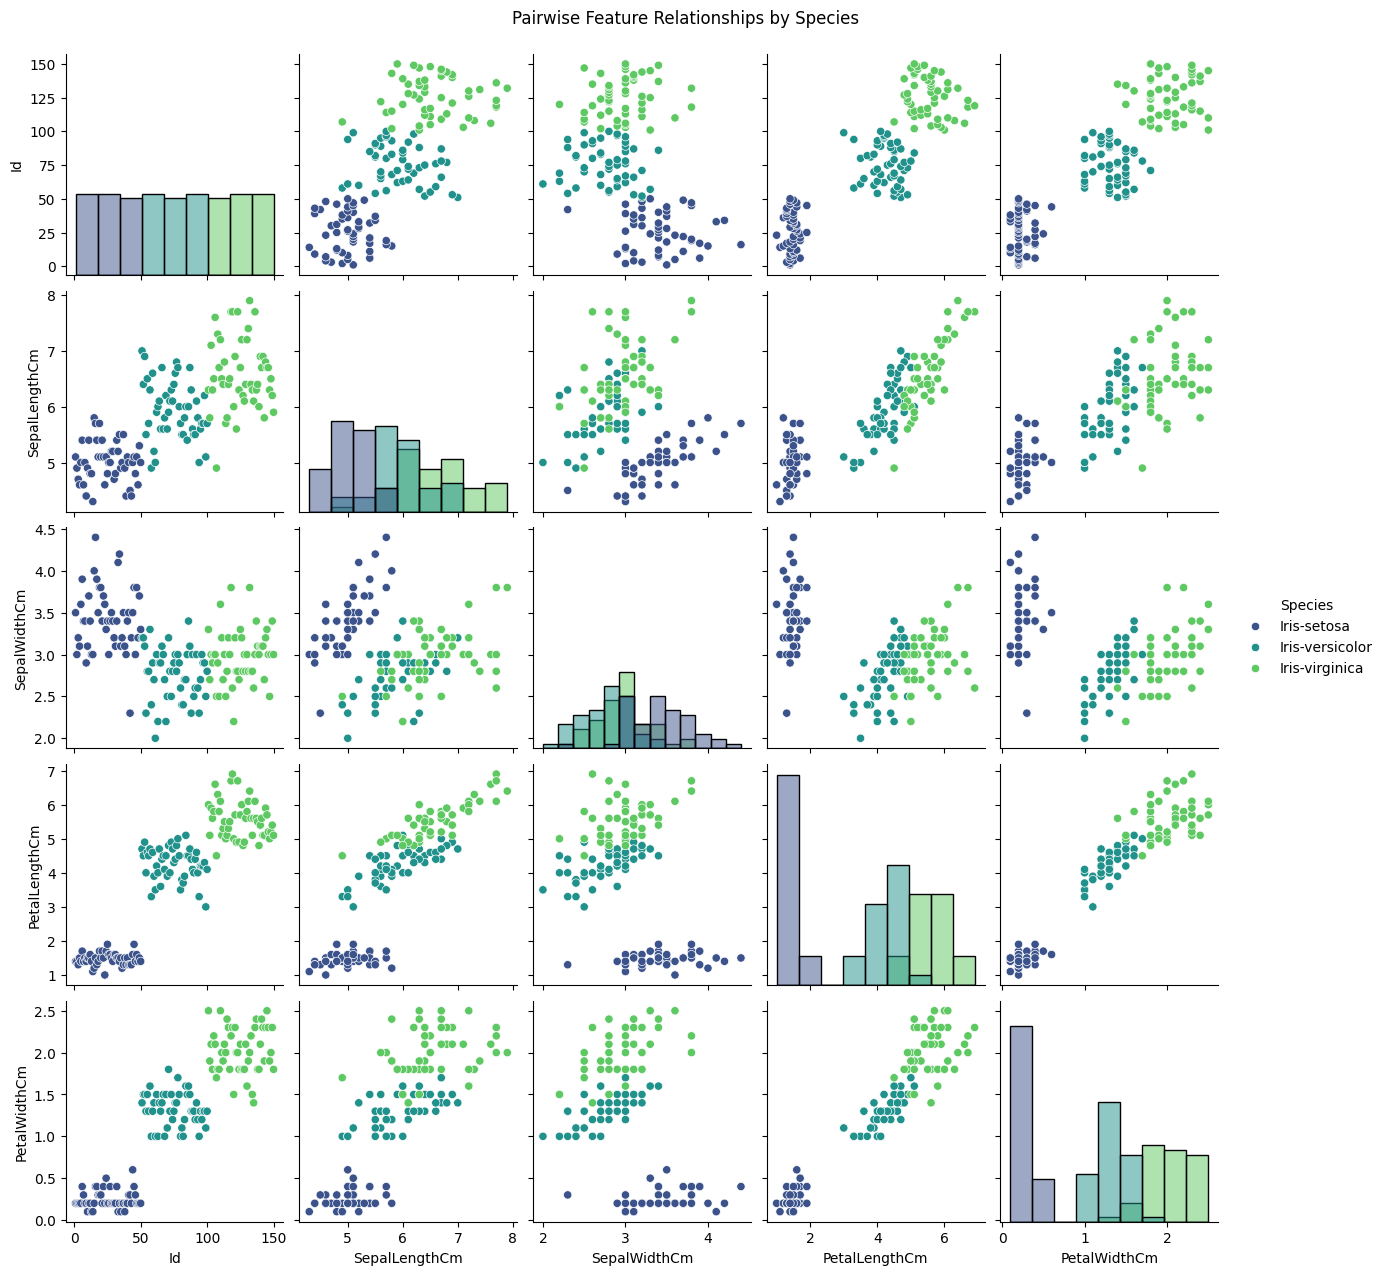

In [32]:
sns.pairplot(df,hue="Species",palette="viridis",diag_kind="hist")
plt.suptitle("Pairwise Feature Relationships by Species",y=1.02)
plt.show()

# Heatmap

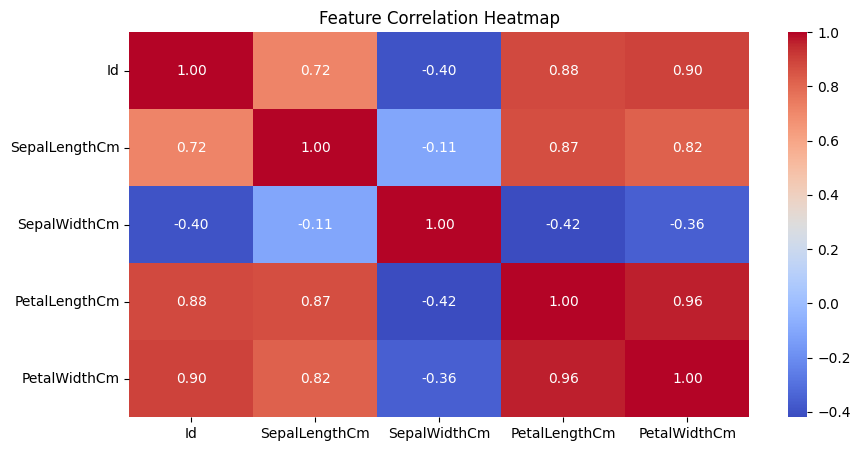

In [33]:
plt.figure(figsize=(10,5))
numeric_df=df.drop(columns=["Species"])
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Boxplots

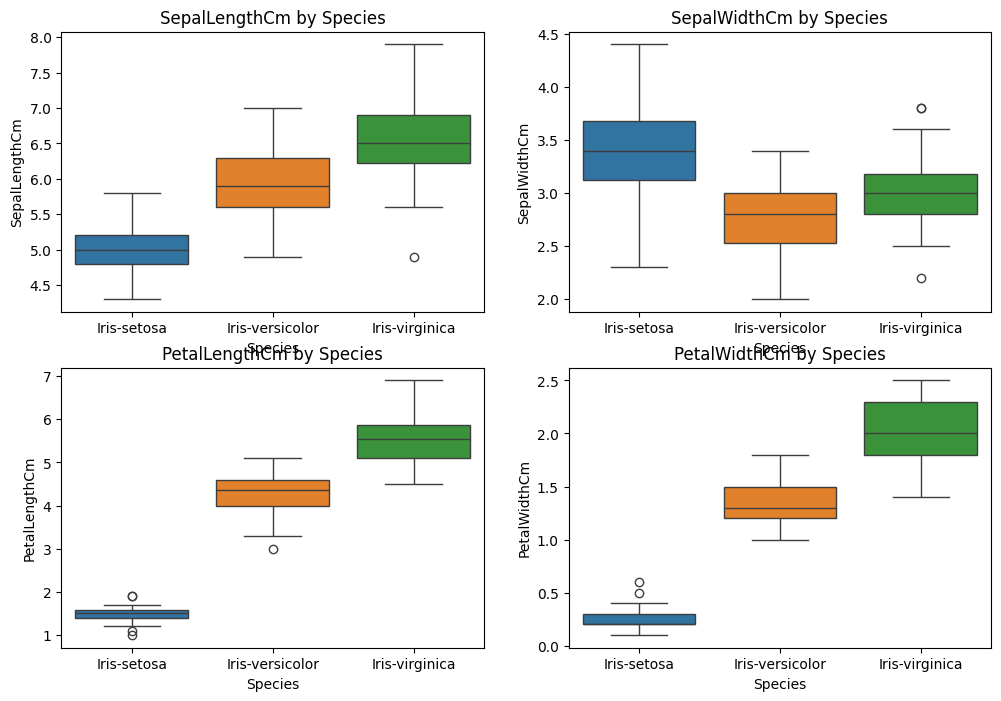

In [34]:
fig,axes=plt.subplots(2,2,figsize=(12,8))
features=["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]

for ax,feature in zip(axes.flatten(),features):
    sns.boxplot(data=df,x="Species",y=feature,hue="Species",ax=ax)
    ax.set_title(f"{feature} by Species")
plt.show()

# Histograms

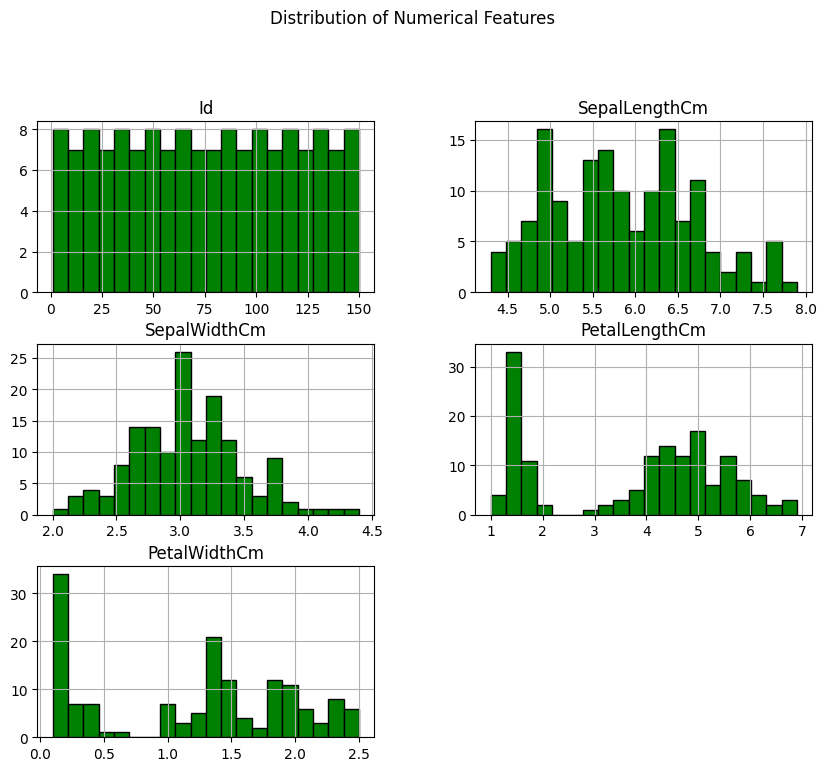

In [35]:
df.drop(columns=["Species"]).hist(bins=20,figsize=(10, 8),color="green",edgecolor="black")
plt.suptitle("Distribution of Numerical Features",y=1.02)
plt.show()

# Violin Plot

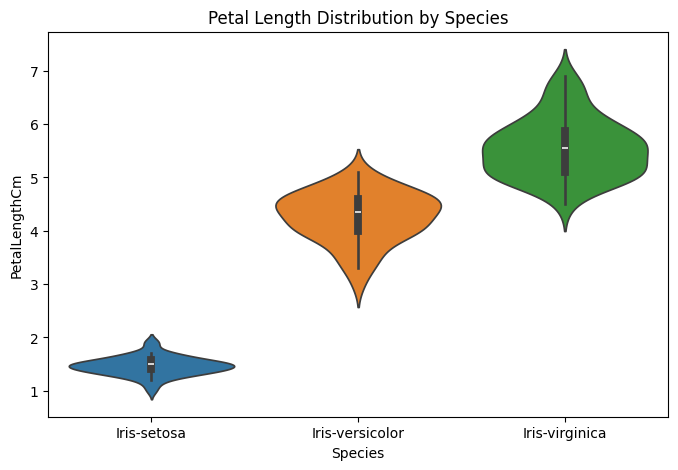

In [36]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df,x="Species",y="PetalLengthCm",hue="Species")
plt.title("Petal Length Distribution by Species")
plt.show()

# Data Preprocessing

In [37]:
X=df.drop(columns=["Species"])
y=df["Species"]

# Encode target labels (Iris-setosa, Iris-versicolor, Iris-virginica -> 0, 1, 2)
le=LabelEncoder()
y_encoded=le.fit_transform(y)
print("Classes:",list(le.classes_))
X_train,X_test,y_train,y_test=train_test_split(X,y_encoded,test_size=0.2,random_state=42,stratify=y_encoded)
print("Training set shape:",X_train.shape)
print("Testing set shape:",X_test.shape)

Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Training set shape: (120, 5)
Testing set shape: (30, 5)


# ML Model

In [38]:
model = RandomForestClassifier(n_estimators=70, random_state=30)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=70, random_state=30)

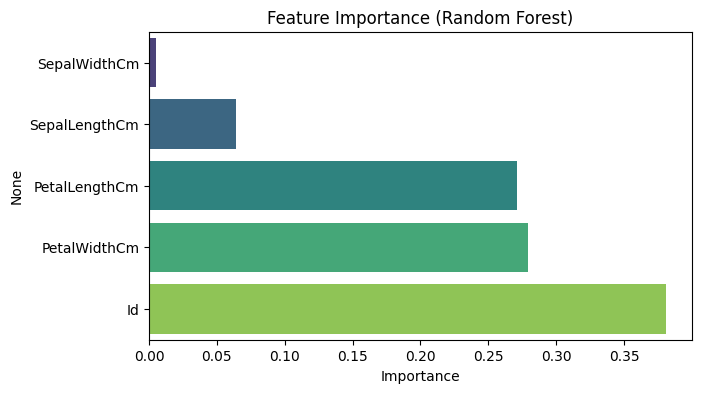

SepalWidthCm     0.004882
SepalLengthCm    0.063821
PetalLengthCm    0.271009
PetalWidthCm     0.279519
Id               0.380769
dtype: float64


In [39]:
importances=pd.Series(model.feature_importances_,index=X.columns).sort_values()

plt.figure(figsize=(7,4))
sns.barplot(x=importances.values,y=importances.index,hue=importances.index,palette="viridis",legend=False)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

print(importances)

# Model Evaluation

# Accuracy

In [40]:
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy:.2f}({accuracy*100:.2f}%)")

Accuracy:1.00(100.00%)


# f1-score

In [41]:
f1_scores=f1_score(y_test,y_pred,average=None)
print("F1 Score for each class:")
print(f1_scores)

F1 Score for each class:
[1. 1. 1.]


# Confusion Matrix

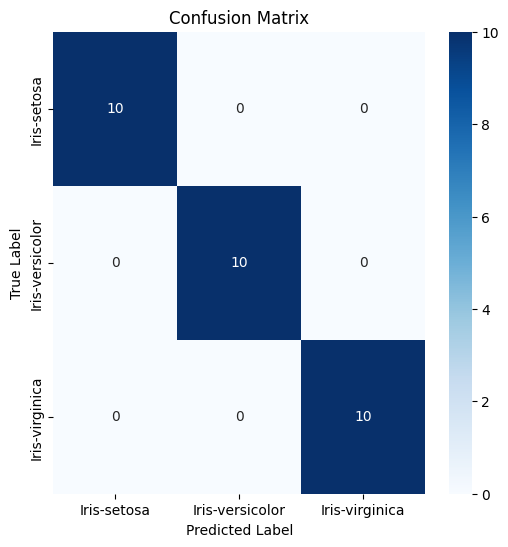

In [42]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm,annot=True,cmap="Blues",xticklabels=le.classes_,yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report

In [43]:
report=classification_report(y_test,y_pred,target_names=le.classes_)
print(report)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

